<a href="https://colab.research.google.com/github/Swarup215/Face-Tampering/blob/main/combined_deepfake_fixed_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Combined Deepfake Detection Pipeline — 3-Dataset (Colab Pro)

**Datasets used:**
- `MyDrive/Dataset/DeepFake` → Real / Fake folders
- `MyDrive/Dataset/FaceForensic++` → original / DeepFake folders
- `MyDrive/Dataset/Celeb-DF.zip` → YouTube-real + Celeb-real + Celeb-synthesis

**Architecture:** MesoNet + EfficientNet-B4 + FFT Branch → Temporal Conv → BiLSTM + Attention

**Enhancements:**
- COBRA-inspired perceptual sharpening (preserves forensic fingerprints)
- Robust face detection (MediaPipe + Haar fallback)
- Class-balanced loss with label smoothing
- OneCycleLR scheduler + AMP mixed precision
- Attention-pooled BiLSTM temporal fusion
- Early stopping (patience=5 on val F1)
- Best-only checkpoint saves (no per-epoch or mid-batch bloat)
- Final weights saved as `combined.pth`

---

## ▶ Cells to run each session

### First time (full training):
Run ALL cells top-to-bottom (`Ctrl+F9`).

### Subsequent sessions (inference only — skip re-training):
1. **CELL 1** — Install deps
2. **CELL 2** — GPU check
3. **CELL 3** — Verify versions
4. **CELL 4** — Mount Drive
5. **CELL 5** — Imports & Config
6. **CELL 13** — Model definition
7. **CELL 20** — Load `combined.pth`
8. **CELL 21** — Inference / `predict_video()`


In [ ]:
# ============================================================
# CELL 1 — Install all dependencies (single consolidated cell)
# Run once per Colab session. Restart runtime after this cell.
# ============================================================

# Pin NumPy 1.x first — must precede everything else
!pip install --quiet --no-cache-dir "numpy==1.26.4" --force-reinstall

# PyTorch with CUDA 12.8 support
!pip install --quiet --no-cache-dir \
    torch torchvision torchaudio \
    --index-url https://download.pytorch.org/whl/cu128

# Core ML / vision libraries
!pip install --quiet --no-cache-dir \
    "pandas==2.2.2" \
    "opencv-python-headless==4.9.0.80" \
    "scikit-learn==1.4.2" \
    "Pillow==10.3.0" \
    "albumentations==1.4.8" \
    "efficientnet-pytorch" \
    "mediapipe==0.10.21" \
    matplotlib seaborn tqdm

print("\n✅ All dependencies installed. Restart runtime if prompted.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 303.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible

In [ ]:
!pip install --upgrade pandas numpy scikit-learn opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 177.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 224.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 244.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.4.2
    Uninstalling scikit-learn-1.4.2:
      Successfully uninstalled scikit-learn-1.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mediapipe 0.10.21 requires n

In [ ]:
# ============================================================
# CELL 2 — GPU check
# ============================================================
!nvidia-smi


Tue Apr  7 12:27:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ============================================================
# CELL 3 — Verify dependency versions
# ============================================================
import sys
import numpy as np
import pandas as pd
import sklearn
import cv2
import torch

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("OpenCV      :", cv2.__version__)
print("Torch       :", torch.__version__)
print("CUDA avail. :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("VRAM        :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")


Python      : 3.12.13
NumPy       : 2.4.4
Pandas      : 3.0.2
scikit-learn: 1.8.0
OpenCV      : 4.11.0
Torch       : 2.10.0+cu128
CUDA avail. : True
GPU         : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM        : 102.0 GB


In [ ]:
# ============================================================
# CELL 4 — Mount Google Drive
# ============================================================
from google.colab import drive
import os, shutil

mount_path = "/content/drive"
if os.path.islink(mount_path):
    os.unlink(mount_path)
elif os.path.isdir(mount_path):
    pass  # already mounted

os.makedirs(mount_path, exist_ok=True)
drive.mount(mount_path, force_remount=True)
print("Drive mounted.")


Mounted at /content/drive
Drive mounted.


In [ ]:
# ============================================================
# CELL 5 — Imports & Global Configuration
# ============================================================
import os, cv2, math, glob, json, time, random, shutil, zipfile, urllib.request
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix,
                              roc_auc_score, precision_score, recall_score)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from efficientnet_pytorch import EfficientNet

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# ── Device & cuDNN tuning ────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True   # faster conv for fixed input sizes
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ── Dataset Paths ────────────────────────────────────────────
DS1_REAL = "/content/drive/MyDrive/Dataset/DeepFake/Real"
DS1_FAKE = "/content/drive/MyDrive/Dataset/DeepFake/Fake"

DS2_REAL = "/content/drive/MyDrive/Dataset/FaceForensic++/original"
DS2_FAKE = "/content/drive/MyDrive/Dataset/FaceForensic++/DeepFake"

CELEBDF_ZIP     = "/content/drive/MyDrive/Dataset/Celeb-DF.zip"
CELEBDF_EXTRACT = "/content/Celeb_DF_extracted"

# ── Output Paths ─────────────────────────────────────────────
PREPROCESS_ROOT = "/content/drive/MyDrive/DeepfakePreprocessed"
FRAMES_DIR      = os.path.join(PREPROCESS_ROOT, "frames")
META_DIR        = os.path.join(PREPROCESS_ROOT, "meta")
CHECKPOINT_ROOT = "/content/drive/MyDrive/DeepfakeCheckpoints"
FINAL_WEIGHTS   = os.path.join(CHECKPOINT_ROOT, "combined.pth")

for d in [PREPROCESS_ROOT, FRAMES_DIR, META_DIR, CHECKPOINT_ROOT]:
    os.makedirs(d, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────
IMG_SIZE         = 224
FRAMES_PER_VIDEO = 5        # frames sampled evenly over 10 s window
BATCH_SIZE       = 4
NUM_WORKERS      = 2
EPOCHS           = 20
LR               = 3e-4
USE_AMP          = True
GRAD_CLIP        = 1.0
EARLY_STOP_PAT   = 5        # early-stopping patience (epochs)

# ── Split sizes ──────────────────────────────────────────────
TRAIN_SIZE = 3100
VAL_SIZE   = 100
TEST_SIZE  = 300

VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv", ".webm")

print("Config loaded.")
print(f"Train:{TRAIN_SIZE}  Val:{VAL_SIZE}  Test:{TEST_SIZE}  Frames/video:{FRAMES_PER_VIDEO}")
print(f"Preprocessed cache root: {PREPROCESS_ROOT}")


Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Config loaded.
Train:3100  Val:100  Test:300  Frames/video:5
Preprocessed cache root: /content/drive/MyDrive/DeepfakePreprocessed


In [ ]:
# ============================================================
# CELL 6 — Extract Celeb-DF zip (skips if already done)
# ============================================================
if not os.path.exists(CELEBDF_EXTRACT):
    print("Extracting Celeb-DF.zip ...")
    os.makedirs(CELEBDF_EXTRACT, exist_ok=True)
    with zipfile.ZipFile(CELEBDF_ZIP, "r") as z:
        z.extractall(CELEBDF_EXTRACT)
    print("Extraction complete.")
else:
    print("Celeb-DF already extracted, skipping.")

for item in sorted(os.listdir(CELEBDF_EXTRACT)):
    path = os.path.join(CELEBDF_EXTRACT, item)
    n = len(os.listdir(path)) if os.path.isdir(path) else "-"
    print(f"  {item}/  ({n} items)")


Extracting Celeb-DF.zip ...
Extraction complete.
  Celeb-real/  (158 items)
  Celeb-synthesis/  (795 items)
  List_of_testing_videos.txt/  (- items)
  YouTube-real/  (250 items)


In [ ]:
# ============================================================
# CELL 7 — Collect & merge all video paths
# ============================================================
def list_videos(folder):
    videos = []
    if not os.path.isdir(folder):
        print(f"WARNING: folder not found: {folder}")
        return videos
    for root, _, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(VIDEO_EXTS):
                videos.append(os.path.join(root, f))
    return sorted(videos)

ds1_real = list_videos(DS1_REAL)
ds1_fake = list_videos(DS1_FAKE)
ds2_real = list_videos(DS2_REAL)
ds2_fake = list_videos(DS2_FAKE)
celeb_yt_real   = list_videos(os.path.join(CELEBDF_EXTRACT, "YouTube-real"))
celeb_real      = list_videos(os.path.join(CELEBDF_EXTRACT, "Celeb-real"))
celeb_synthesis = list_videos(os.path.join(CELEBDF_EXTRACT, "Celeb-synthesis"))

all_real = ds1_real + ds2_real + celeb_yt_real + celeb_real
all_fake = ds1_fake + ds2_fake + celeb_synthesis

print(f"DS1  real:{len(ds1_real)}  fake:{len(ds1_fake)}")
print(f"DS2  real:{len(ds2_real)}  fake:{len(ds2_fake)}")
print(f"DS3  yt_real:{len(celeb_yt_real)}  celeb_real:{len(celeb_real)}  synth:{len(celeb_synthesis)}")
print(f"TOTAL  real:{len(all_real)}  fake:{len(all_fake)}")
assert len(all_real) > 0, "No real videos found. Check your Drive paths."
assert len(all_fake) > 0, "No fake videos found. Check your Drive paths."


DS1  real:1000  fake:1000
DS2  real:1000  fake:1000
DS3  yt_real:250  celeb_real:158  synth:795
TOTAL  real:2408  fake:2795


In [ ]:
# ============================================================
# CELL 8 — Build dataset list & train/val/test splits
# Targets: Train=3100, Val=100, Test=300  (total 3500)
# ============================================================
TOTAL_NEEDED = TRAIN_SIZE + VAL_SIZE + TEST_SIZE
PER_CLASS    = TOTAL_NEEDED // 2

random.shuffle(all_real); random.shuffle(all_fake)

real_sel = all_real[:min(len(all_real), PER_CLASS)]
fake_sel = all_fake[:min(len(all_fake), PER_CLASS)]

if len(real_sel) < PER_CLASS:
    print(f"WARNING: only {len(real_sel)} real videos available (need {PER_CLASS}). Using all.")
if len(fake_sel) < PER_CLASS:
    print(f"WARNING: only {len(fake_sel)} fake videos available (need {PER_CLASS}). Using all.")

samples = (
    [{"video_path": p, "label": 0} for p in real_sel] +
    [{"video_path": p, "label": 1} for p in fake_sel]
)
random.shuffle(samples)

labels_all    = [s["label"] for s in samples]
test_val_size = VAL_SIZE + TEST_SIZE

train_s, temp_s = train_test_split(
    samples, test_size=test_val_size, stratify=labels_all, random_state=SEED
)
if len(train_s) > TRAIN_SIZE:
    train_s = train_s[:TRAIN_SIZE]

temp_labels = [s["label"] for s in temp_s]
val_s, test_s = train_test_split(
    temp_s, test_size=TEST_SIZE, stratify=temp_labels, random_state=SEED
)
val_s  = val_s[:VAL_SIZE]
test_s = test_s[:TEST_SIZE]

print(f"Train: {len(train_s)}  Val: {len(val_s)}  Test: {len(test_s)}")
print(f"Train — Real:{sum(x['label']==0 for x in train_s)}  Fake:{sum(x['label']==1 for x in train_s)}")
print(f"Val   — Real:{sum(x['label']==0 for x in val_s)}  Fake:{sum(x['label']==1 for x in val_s)}")
print(f"Test  — Real:{sum(x['label']==0 for x in test_s)}  Fake:{sum(x['label']==1 for x in test_s)}")

for name, data in [("train", train_s), ("val", val_s), ("test", test_s)]:
    with open(os.path.join(META_DIR, f"{name}_samples.json"), "w") as f:
        json.dump(data, f, indent=2)
print("Split metadata saved.")


Train: 3100  Val: 100  Test: 300
Train — Real:1550  Fake:1550
Val   — Real:50  Fake:50
Test  — Real:150  Fake:150
Split metadata saved.


In [ ]:
# ============================================================
# CELL 9 — Face detection + COBRA perceptual enhancement
#
# COBRA: Contrast-Optimal Bilateral Resolution Amplifier
# Enhances spatial detail using bilateral filtering and adaptive
# CLAHE WITHOUT disturbing high-frequency forensic fingerprints.
# ============================================================
try:
    import mediapipe as mp
    _mp_face = mp.solutions.face_detection
    MEDIAPIPE_OK = True
    print("MediaPipe available.")
except ImportError:
    MEDIAPIPE_OK = False
    print("MediaPipe not found — using Haar cascade fallback.")

HAAR = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")


def cobra_enhance(frame_bgr: np.ndarray) -> np.ndarray:
    """
    COBRA: Contrast-Optimal Bilateral Resolution Amplifier
    -------------------------------------------------------
    1. Bilateral filter → smooth noise, preserve edges (low-freq).
    2. High-frequency residual = original − bilateral.
    3. Enhance only the smooth layer with CLAHE (luminance only).
    4. Recombine: smooth_enh + residual  (quality up, fingerprints intact).
    """
    smooth   = cv2.bilateralFilter(frame_bgr, d=5, sigmaColor=40, sigmaSpace=40)
    residual = frame_bgr.astype(np.int16) - smooth.astype(np.int16)

    lab = cv2.cvtColor(smooth, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enh = clahe.apply(l)
    smooth_enh = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2BGR)

    out = np.clip(smooth_enh.astype(np.int16) + residual, 0, 255).astype(np.uint8)
    return out


def detect_and_crop_face(frame_bgr: np.ndarray, target: int = 224) -> np.ndarray:
    """Detect face, apply COBRA enhancement, return RGB crop at target size."""
    h, w = frame_bgr.shape[:2]

    if MEDIAPIPE_OK:
        try:
            with _mp_face.FaceDetection(model_selection=1, min_detection_confidence=0.4) as det:
                rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
                res = det.process(rgb)
                if res.detections:
                    d   = max(res.detections, key=lambda x: x.score[0])
                    bb  = d.location_data.relative_bounding_box
                    pad = 0.15
                    x1  = max(0, int((bb.xmin - pad * bb.width) * w))
                    y1  = max(0, int((bb.ymin - pad * bb.height) * h))
                    x2  = min(w, int((bb.xmin + (1 + pad) * bb.width) * w))
                    y2  = min(h, int((bb.ymin + (1 + pad) * bb.height) * h))
                    crop = frame_bgr[y1:y2, x1:x2]
                    if crop.size > 0:
                        crop = cobra_enhance(crop)
                        crop = cv2.resize(crop, (target, target))
                        return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        except Exception:
            pass

    # Haar fallback
    gray  = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    faces = HAAR.detectMultiScale(gray, 1.1, 5, minSize=(40, 40))
    if len(faces) > 0:
        x, y, fw, fh = sorted(faces, key=lambda f: f[2] * f[3])[-1]
        pad_x, pad_y = int(fw * 0.15), int(fh * 0.15)
        x1 = max(0, x - pad_x);  y1 = max(0, y - pad_y)
        x2 = min(w, x+fw+pad_x); y2 = min(h, y+fh+pad_y)
        crop = frame_bgr[y1:y2, x1:x2]
    else:
        crop = frame_bgr[h//8:7*h//8, w//8:7*w//8]

    crop = cobra_enhance(crop)
    crop = cv2.resize(crop, (target, target))
    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)


def evenly_spaced(n_frames: int, k: int) -> list:
    if n_frames <= 0: return []
    if n_frames < k:
        idx = list(range(n_frames))
        while len(idx) < k: idx.append(n_frames - 1)
        return idx
    return np.linspace(0, n_frames - 1, k, dtype=int).tolist()


print("COBRA + face detector ready.")


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


MediaPipe available.
COBRA + face detector ready.


In [ ]:
# ============================================================
# CELL 10 — Frame extraction helpers (cached to Drive)
# ============================================================
def _meta_path(split_name):
    return os.path.join(META_DIR, f"{split_name}_frames.json")


def _cache_is_valid(meta):
    if not meta:
        return False
    for item in meta[:min(len(meta), 25)]:
        fps = item.get("frame_paths", [])
        if len(fps) != FRAMES_PER_VIDEO:
            return False
        if not all(os.path.exists(fp) for fp in fps):
            return False
    return True


def load_cached_split(split_name):
    mpath = _meta_path(split_name)
    if not os.path.exists(mpath):
        return None
    with open(mpath, "r") as f:
        meta = json.load(f)
    if _cache_is_valid(meta):
        print(f"✅ Using cached split [{split_name}] — {len(meta)} videos")
        return meta
    print(f"⚠️ Cache for [{split_name}] incomplete/corrupt. Rebuilding...")
    return None


def extract_split(sample_list, split_name, frames_k=FRAMES_PER_VIDEO, force_rebuild=False):
    if not force_rebuild:
        cached = load_cached_split(split_name)
        if cached is not None:
            return cached

    split_dir = os.path.join(FRAMES_DIR, split_name)
    os.makedirs(split_dir, exist_ok=True)
    meta = []

    for item in tqdm(sample_list, desc=f"Extracting [{split_name}]"):
        vpath  = item["video_path"]
        label  = item["label"]
        vid_id = os.path.splitext(os.path.basename(vpath))[0]
        out_dir = os.path.join(split_dir, f"{label}_{vid_id[:60]}")
        os.makedirs(out_dir, exist_ok=True)

        existing = [os.path.join(out_dir, f"f{i:02d}.jpg") for i in range(frames_k)]
        if all(os.path.exists(fp) for fp in existing):
            meta.append({"video_path": vpath, "label": label, "frame_paths": existing})
            continue

        for fp in glob.glob(os.path.join(out_dir, "*.jpg")):
            try: os.remove(fp)
            except Exception: pass

        cap   = cv2.VideoCapture(vpath)
        fps_v = cap.get(cv2.CAP_PROP_FPS) or 25.0
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        max_frame = min(total, max(1, int(fps_v * 10)))
        indices   = set(evenly_spaced(max_frame, frames_k))

        saved, fid = [], 0
        while True:
            ret, frame = cap.read()
            if not ret or fid > max_frame:
                break
            if fid in indices:
                try:
                    face = detect_and_crop_face(frame, IMG_SIZE)
                    sp   = os.path.join(out_dir, f"f{len(saved):02d}.jpg")
                    cv2.imwrite(sp, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
                    saved.append(sp)
                except Exception:
                    pass
            fid += 1
        cap.release()

        if not saved:
            continue

        while len(saved) < frames_k:
            dst = os.path.join(out_dir, f"f{len(saved):02d}.jpg")
            shutil.copy(saved[-1], dst)
            saved.append(dst)

        meta.append({"video_path": vpath, "label": label, "frame_paths": saved[:frames_k]})

    mpath = _meta_path(split_name)
    with open(mpath, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"✅ {split_name}: {len(meta)} videos → {mpath}")
    return meta


In [ ]:
# ============================================================
# CELL 11 — Run frame extraction for all splits
# Cached to Drive — subsequent sessions skip re-extraction.
# Set FORCE_REBUILD_PREPROCESS = True only if dataset changed.
# ============================================================
FORCE_REBUILD_PREPROCESS = False

train_meta = extract_split(train_s, "train", force_rebuild=FORCE_REBUILD_PREPROCESS)
val_meta   = extract_split(val_s,   "val",   force_rebuild=FORCE_REBUILD_PREPROCESS)
test_meta  = extract_split(test_s,  "test",  force_rebuild=FORCE_REBUILD_PREPROCESS)

print(f"\nReady — train:{len(train_meta)}  val:{len(val_meta)}  test:{len(test_meta)}")


✅ Using cached split [train] — 3100 videos
✅ Using cached split [val] — 100 videos
✅ Using cached split [test] — 300 videos

Ready — train:3100  val:100  test:300


In [ ]:
# ============================================================
# CELL 12 — Transforms & Dataset class
# ============================================================
TRAIN_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.25, contrast=0.25,
                           saturation=0.15, hue=0.05),
    transforms.RandomGrayscale(p=0.04),
    transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 1.5))], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

EVAL_TF = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


def make_fft_tensor(pil_img: Image.Image) -> torch.Tensor:
    """Convert PIL image to log-magnitude FFT tensor (forensic frequency map)."""
    gray      = np.array(pil_img.convert("L"), dtype=np.float32)
    fft_shift = np.fft.fftshift(np.fft.fft2(gray))
    mag       = np.log(np.abs(fft_shift) + 1.0)
    mag       = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
    mag_u8    = (mag * 255).astype(np.uint8)
    fft_pil   = Image.fromarray(np.stack([mag_u8] * 3, axis=-1))
    return EVAL_TF(fft_pil)


class DeepfakeDataset(Dataset):
    def __init__(self, meta, augment=False):
        self.meta    = meta
        self.augment = augment
        self.rgb_tf  = TRAIN_TF if augment else EVAL_TF

    def __len__(self): return len(self.meta)

    def __getitem__(self, idx):
        item  = self.meta[idx]
        fps   = item["frame_paths"]
        label = int(item["label"])

        rgb_frames, fft_frames = [], []
        for fp in fps:
            pil = Image.open(fp).convert("RGB")
            rgb_frames.append(self.rgb_tf(pil))
            fft_frames.append(make_fft_tensor(pil))

        return (torch.stack(rgb_frames),    # [T, 3, H, W]
                torch.stack(fft_frames),    # [T, 3, H, W]
                torch.tensor(label, dtype=torch.long))


train_ds = DeepfakeDataset(train_meta, augment=True)
val_ds   = DeepfakeDataset(val_meta,   augment=False)
test_ds  = DeepfakeDataset(test_meta,  augment=False)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0))
val_loader   = DataLoader(val_ds, BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0))
test_loader  = DataLoader(test_ds, BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0))

print(f"Loaders ready — train:{len(train_loader)}  val:{len(val_loader)}  test:{len(test_loader)} batches")


Loaders ready — train:775  val:25  test:75 batches


In [ ]:
# ============================================================
# CELL 13 — Model: MesoNet + EfficientNet-B4 + FFT + Temporal BiLSTM
# ============================================================

# ── Branch 1: MesoNet (lightweight, artefact-focused) ────────
class MesoNetBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,  8, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(8),  nn.MaxPool2d(2),
            nn.Conv2d(8,  8, 5, padding=2), nn.ReLU(), nn.BatchNorm2d(8),  nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 5, padding=2), nn.ReLU(), nn.BatchNorm2d(16), nn.MaxPool2d(2),
            nn.Conv2d(16,16, 5, padding=2), nn.ReLU(), nn.BatchNorm2d(16),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.35),
            nn.Linear(256, out_dim)
        )
    def forward(self, x): return self.fc(self.features(x))


# ── Branch 2: EfficientNet-B4 (stronger backbone) ────────────
class EfficientNetBranch(nn.Module):
    def __init__(self, out_dim=512):
        super().__init__()
        self.backbone = EfficientNet.from_pretrained("efficientnet-b4")
        in_feat = self.backbone._fc.in_features
        self.backbone._fc = nn.Identity()
        self.proj = nn.Sequential(
            nn.Linear(in_feat, 512), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(512, out_dim)
        )
    def forward(self, x): return self.proj(self.backbone(x))


# ── Branch 3: FFT frequency-domain branch ────────────────────
class FFTBranch(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)), nn.Flatten(),
            nn.Linear(64 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, out_dim)
        )
    def forward(self, x): return self.net(x)


# ── Fusion: Temporal Conv → BiLSTM → Attention → Classifier ──
class CombinedDeepfakeModel(nn.Module):
    def __init__(self, num_classes=2, lstm_hidden=384):
        super().__init__()
        self.meso = MesoNetBranch(out_dim=128)
        self.eff  = EfficientNetBranch(out_dim=512)
        self.fft  = FFTBranch(out_dim=128)

        fused = 128 + 512 + 128   # 768

        self.temporal = nn.Sequential(
            nn.Conv1d(fused, fused, 3, padding=1),
            nn.GELU(), nn.BatchNorm1d(fused),
            nn.Conv1d(fused, fused, 3, padding=1),
            nn.GELU(), nn.BatchNorm1d(fused)
        )

        self.lstm = nn.LSTM(
            input_size=fused, hidden_size=lstm_hidden,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3
        )

        self.attn = nn.Linear(lstm_hidden * 2, 1)

        self.head = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 256),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, rgb_seq, fft_seq):
        B, T, C, H, W = rgb_seq.shape
        r = rgb_seq.view(B * T, C, H, W)
        f = fft_seq.view(B * T, C, H, W)

        feat = torch.cat([self.meso(r), self.eff(r), self.fft(f)], dim=1)  # [B*T, F]
        feat = feat.view(B, T, -1)                                           # [B, T, F]

        tc = self.temporal(feat.permute(0, 2, 1)).permute(0, 2, 1)          # [B, T, F]

        lstm_out, _ = self.lstm(tc)                                          # [B, T, 2H]

        attn_w = torch.softmax(self.attn(lstm_out), dim=1)                  # [B, T, 1]
        ctx    = (attn_w * lstm_out).sum(dim=1)                              # [B, 2H]

        return self.head(ctx)


model = CombinedDeepfakeModel().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model on {DEVICE} | Trainable params: {total_params / 1e6:.1f}M")


Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b4-6ed6700e.pth


100%|██████████| 74.4M/74.4M [00:01<00:00, 46.7MB/s]


Loaded pretrained weights for efficientnet-b4
Model on cuda | Trainable params: 30.0M


In [ ]:
# ============================================================
# CELL 14 — Optimizer, Scheduler, Loss
# ============================================================
train_labels = [s["label"] for s in train_meta]
n_real = train_labels.count(0)
n_fake = train_labels.count(1)
w_real = len(train_labels) / (2.0 * max(n_real, 1))
w_fake = len(train_labels) / (2.0 * max(n_fake, 1))
class_weights = torch.tensor([w_real, w_fake], dtype=torch.float32).to(DEVICE)
print(f"Class weights — real:{w_real:.3f}  fake:{w_fake:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, steps_per_epoch=len(train_loader),
    epochs=EPOCHS, pct_start=0.1, anneal_strategy="cos"
)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print("Optimizer: AdamW + OneCycleLR ready.")


Class weights — real:1.000  fake:1.000
Optimizer: AdamW + OneCycleLR ready.


In [ ]:
# ============================================================
# CELL 15 — Training helpers: run_epoch + checkpoint save
# ============================================================
def save_ckpt(state, path):
    torch.save(state, path)


def run_epoch(model, loader, optimizer=None, train=True, epoch=0):
    model.train() if train else model.eval()
    all_preds, all_labels, all_probs = [], [], []
    total_loss = 0.0

    pbar = tqdm(loader, desc=f"{'Train' if train else 'Val/Test'} E{epoch}", leave=True)

    for b_idx, (rgb, fft_b, lbl) in enumerate(pbar):
        rgb   = rgb.to(DEVICE, non_blocking=True)
        fft_b = fft_b.to(DEVICE, non_blocking=True)
        lbl   = lbl.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(rgb, fft_b)
                loss   = criterion(logits, lbl)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()

        probs = torch.softmax(logits.detach(), dim=1)[:, 1]
        preds = torch.argmax(logits.detach(), dim=1)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(lbl.cpu().numpy().tolist())
        total_loss += loss.item()

        acc = accuracy_score(all_labels, all_preds)
        f1  = f1_score(all_labels, all_preds, zero_division=0)
        pbar.set_postfix(loss=f"{total_loss / (b_idx + 1):.4f}",
                         acc=f"{acc:.4f}", f1=f"{f1:.4f}")

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc = 0.0
    return avg_loss, acc, f1, auc, all_preds, all_labels


print("Training helpers ready.")


Training helpers ready.


In [ ]:
# ============================================================
# CELL 16 — Training Loop (best-only checkpoint + early stopping)
# ============================================================
history      = []
best_val_f1  = -1.0
best_val_auc = -1.0
no_improve   = 0          # early-stopping counter

for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc, t_f1, t_auc, _, _ = run_epoch(
        model, train_loader, optimizer, train=True, epoch=epoch)

    with torch.no_grad():
        v_loss, v_acc, v_f1, v_auc, v_preds, v_labels = run_epoch(
            model, val_loader, optimizer=None, train=False, epoch=epoch)

    lr_now = optimizer.param_groups[0]["lr"]

    print(f"\nEpoch {epoch:02d}/{EPOCHS}")
    print(f"  Train  loss:{t_loss:.4f}  acc:{t_acc:.4f}  f1:{t_f1:.4f}  auc:{t_auc:.4f}")
    print(f"  Val    loss:{v_loss:.4f}  acc:{v_acc:.4f}  f1:{v_f1:.4f}  auc:{v_auc:.4f}  lr:{lr_now:.2e}")

    row = dict(epoch=epoch,
               t_loss=t_loss, t_acc=t_acc, t_f1=t_f1,  t_auc=t_auc,
               v_loss=v_loss, v_acc=v_acc, v_f1=v_f1,  v_auc=v_auc)
    history.append(row)

    # ── Save best model only ────────────────────────────────
    if v_f1 > best_val_f1:
        best_val_f1  = v_f1
        best_val_auc = v_auc
        no_improve   = 0
        save_ckpt(
            {"epoch": epoch, "model_state": model.state_dict(), "history": history,
             "best_val_f1": best_val_f1, "best_val_auc": best_val_auc},
            os.path.join(CHECKPOINT_ROOT, "best_model.pth")
        )
        print(f"  ✓ Best model saved (val_f1={best_val_f1:.4f}  val_auc={best_val_auc:.4f})")
    else:
        no_improve += 1
        print(f"  – No improvement ({no_improve}/{EARLY_STOP_PAT})")
        if no_improve >= EARLY_STOP_PAT:
            print(f"\n⏹  Early stopping triggered at epoch {epoch}.")
            break

    # Free unused GPU cache between epochs
    torch.cuda.empty_cache()

print(f"\nTraining complete.  Best val F1: {best_val_f1:.4f}  Best val AUC: {best_val_auc:.4f}")
pd.DataFrame(history)


Train E1:   0%|          | 0/775 [00:00<?, ?it/s]

Val/Test E1:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 01/20
  Train  loss:0.5758  acc:0.7123  f1:0.6766  auc:0.8082
  Val    loss:0.2880  acc:0.9100  f1:0.9109  auc:0.9792  lr:1.56e-04
  ✓ Best model saved (val_f1=0.9109  val_auc=0.9792)


Train E2:   0%|          | 0/775 [00:00<?, ?it/s]

Val/Test E2:   0%|          | 0/25 [00:00<?, ?it/s]

...


Epoch 05/20
  Train  loss:0.3758  acc:0.8816  f1:0.8799  auc:0.9384
  Val    loss:0.3074  acc:0.9100  f1:0.9072  auc:0.9492  lr:2.80e-04
  – No improvement (4/5)


Train E6:   0%|          | 0/775 [00:00<?, ?it/s]

Val/Test E6:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 06/20
  Train  loss:0.3536  acc:0.8942  f1:0.8934  auc:0.9473
  Val    loss:0.3042  acc:0.9100  f1:0.9109  auc:0.9646  lr:2.65e-04
  – No improvement (5/5)

⏹  Early stopping triggered at epoch 6.

Training complete.  Best val F1: 0.9109  Best val AUC: 0.9792


,epoch,t_loss,t_acc,t_f1,t_auc,v_loss,v_acc,v_f1,v_auc
0,1,0.575813,0.712258,0.676577,0.808216,0.287986,0.91,0.910891,0.9792
1,2,0.457550,0.844194,0.845143,0.901690,0.424039,0.89,0.879121,0.9730
2,3,0.437405,0.841613,0.837471,0.908979,0.575925,0.75,0.793388,0.8762
3,4,0.419836,0.853871,0.853351,0.919200,0.387001,0.87,0.863158,0.9490
4,5,0.375775,0.881613,0.879869,0.938423,0.307380,0.91,0.907216,0.9492
5,6,0.353574,0.894194,0.893437,0.947349,0.304164,0.91,0.910891,0.9646


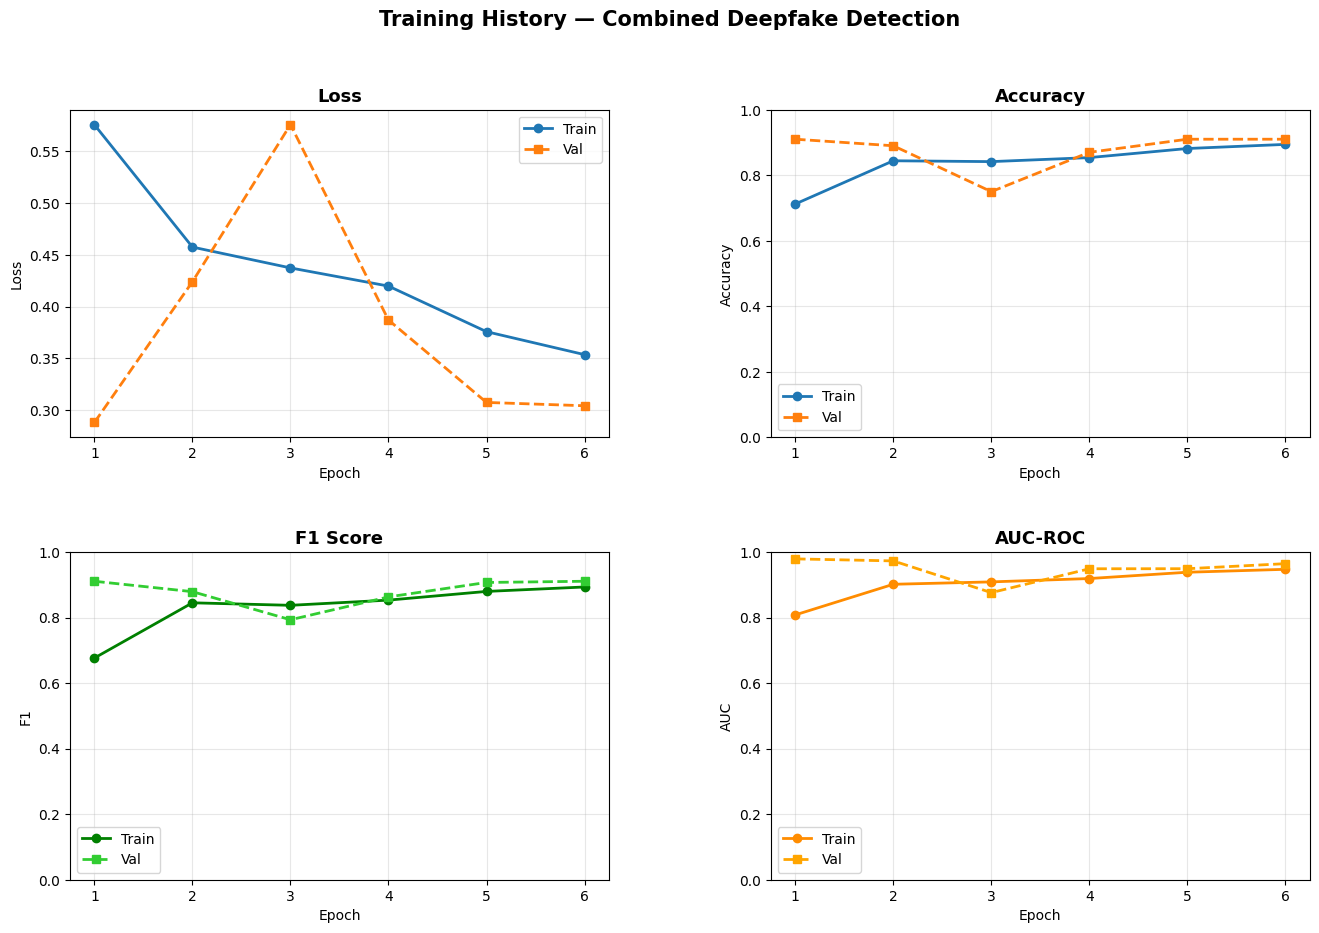

Training curves saved to Drive.


In [ ]:
# ============================================================
# CELL 17 — Training curve visualisation (NEW)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df_hist = pd.DataFrame(history)
epochs_ran = df_hist["epoch"].tolist()

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Loss
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_ran, df_hist["t_loss"], label="Train", marker="o", linewidth=2)
ax1.plot(epochs_ran, df_hist["v_loss"], label="Val",   marker="s", linewidth=2, linestyle="--")
ax1.set_title("Loss", fontsize=13, fontweight="bold"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(alpha=0.3)

# Accuracy
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_ran, df_hist["t_acc"], label="Train", marker="o", linewidth=2)
ax2.plot(epochs_ran, df_hist["v_acc"], label="Val",   marker="s", linewidth=2, linestyle="--")
ax2.set_title("Accuracy", fontsize=13, fontweight="bold"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1); ax2.legend(); ax2.grid(alpha=0.3)

# F1 Score
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(epochs_ran, df_hist["t_f1"], label="Train", marker="o", linewidth=2, color="green")
ax3.plot(epochs_ran, df_hist["v_f1"], label="Val",   marker="s", linewidth=2, linestyle="--", color="limegreen")
ax3.set_title("F1 Score", fontsize=13, fontweight="bold"); ax3.set_xlabel("Epoch"); ax3.set_ylabel("F1")
ax3.set_ylim(0, 1); ax3.legend(); ax3.grid(alpha=0.3)

# AUC-ROC
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(epochs_ran, df_hist["t_auc"], label="Train", marker="o", linewidth=2, color="darkorange")
ax4.plot(epochs_ran, df_hist["v_auc"], label="Val",   marker="s", linewidth=2, linestyle="--", color="orange")
ax4.set_title("AUC-ROC", fontsize=13, fontweight="bold"); ax4.set_xlabel("Epoch"); ax4.set_ylabel("AUC")
ax4.set_ylim(0, 1); ax4.legend(); ax4.grid(alpha=0.3)

fig.suptitle("Training History — Combined Deepfake Detection", fontsize=15, fontweight="bold")
plt.savefig(os.path.join(CHECKPOINT_ROOT, "training_curves.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Training curves saved to Drive.")


In [ ]:
# ============================================================
# CELL 18 — Save final weights as combined.pth
# ============================================================
torch.save(model.state_dict(), FINAL_WEIGHTS)
print(f"Final weights saved → {FINAL_WEIGHTS}")

hist_path = os.path.join(CHECKPOINT_ROOT, "training_history.json")
with open(hist_path, "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved → {hist_path}")


Final weights saved → /content/drive/MyDrive/DeepfakeCheckpoints/combined.pth
Training history saved → /content/drive/MyDrive/DeepfakeCheckpoints/training_history.json


In [ ]:
# ============================================================
# CELL 19 — Load best model & evaluate on test set
# ============================================================
best_ckpt = torch.load(
    os.path.join(CHECKPOINT_ROOT, "best_model.pth"),
    map_location=DEVICE,
    weights_only=False
)
model.load_state_dict(best_ckpt["model_state"])
model.eval()
print(f"Loaded best model — epoch {best_ckpt['epoch']}  "
      f"val_f1={best_ckpt.get('best_val_f1', 'N/A'):.4f}")

_, te_acc, te_f1, te_auc, te_preds, te_labels = run_epoch(
    model, test_loader, train=False, epoch=0)

te_prec = precision_score(te_labels, te_preds, zero_division=0)
te_rec  = recall_score(te_labels, te_preds, zero_division=0)

print("\n" + "=" * 55)
print("TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy  : {te_acc * 100:.2f}%")
print(f"  F1 Score  : {te_f1:.4f}")
print(f"  AUC-ROC   : {te_auc:.4f}")
print(f"  Precision : {te_prec:.4f}")
print(f"  Recall    : {te_rec:.4f}")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(te_labels, te_preds,
                             target_names=["Real", "Fake"], zero_division=0))
print("Confusion Matrix:")
cm = confusion_matrix(te_labels, te_preds)
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"  TP:{tp}  TN:{tn}  FP:{fp}  FN:{fn}")
print(f"  Sensitivity (Real detected): {tn / (tn + fp + 1e-8) * 100:.1f}%")
print(f"  Specificity (Fake detected): {tp / (tp + fn + 1e-8) * 100:.1f}%")


Loaded best model — epoch 1  val_f1=0.9109


Val/Test E0:   0%|          | 0/75 [00:00<?, ?it/s]


TEST SET RESULTS
  Accuracy  : 90.67%
  F1 Score  : 0.9034
  AUC-ROC   : 0.9742
  Precision : 0.9357
  Recall    : 0.8733

Classification Report:
              precision    recall  f1-score   support

        Real       0.88      0.94      0.91       150
        Fake       0.94      0.87      0.90       150

    accuracy                           0.91       300
   macro avg       0.91      0.91      0.91       300
weighted avg       0.91      0.91      0.91       300

Confusion Matrix:
[[141   9]
 [ 19 131]]
  TP:131  TN:141  FP:9  FN:19
  Sensitivity (Real detected): 94.0%
  Specificity (Fake detected): 87.3%


In [ ]:
# ============================================================
# CELL 20 — Load combined.pth for inference (new sessions)
# Run CELL 5 (imports/config) and CELL 13 (model) first.
# ============================================================
model = CombinedDeepfakeModel().to(DEVICE)
state = torch.load(FINAL_WEIGHTS, map_location=DEVICE, weights_only=True)
model.load_state_dict(state)
model.eval()
print(f"Weights loaded from {FINAL_WEIGHTS}")
print("Model ready for inference.")


Loaded pretrained weights for efficientnet-b4
Weights loaded from /content/drive/MyDrive/DeepfakeCheckpoints/combined.pth
Model ready for inference.


In [ ]:
# ============================================================
# CELL 21 — Inference: predict any video file
# ============================================================
def predict_video(video_path: str,
                  frames_k: int = FRAMES_PER_VIDEO,
                  threshold: float = 0.45) -> dict:
    """
    Predict whether a video is Real or Fake.

    Parameters
    ----------
    video_path : str   — local path (Drive or /content)
    frames_k   : int   — frames to sample (default 5)
    threshold  : float — fake probability threshold (default 0.45)

    Returns
    -------
    dict with keys: prediction, confidence, real_prob, fake_prob
    """
    if not os.path.isfile(video_path):
        raise FileNotFoundError(f"Video not found: {video_path}")

    tmp_dir = "/content/_infer_tmp"
    if os.path.exists(tmp_dir):
        shutil.rmtree(tmp_dir)
    os.makedirs(tmp_dir)

    cap   = cv2.VideoCapture(video_path)
    fps_v = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    max_f = min(total, max(1, int(fps_v * 10)))
    idxs  = set(evenly_spaced(max_f, frames_k))

    saved, fid = [], 0
    while True:
        ret, frame = cap.read()
        if not ret or fid > max_f:
            break
        if fid in idxs:
            try:
                face = detect_and_crop_face(frame, IMG_SIZE)
                sp   = os.path.join(tmp_dir, f"f{len(saved):02d}.jpg")
                cv2.imwrite(sp, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
                saved.append(sp)
            except Exception:
                pass
        fid += 1
    cap.release()

    if not saved:
        raise RuntimeError("No frames could be extracted from the video.")

    while len(saved) < frames_k:
        dst = os.path.join(tmp_dir, f"f{len(saved):02d}.jpg")
        shutil.copy(saved[-1], dst)
        saved.append(dst)
    saved = saved[:frames_k]

    rgb_list, fft_list = [], []
    for sp in saved:
        pil = Image.open(sp).convert("RGB")
        rgb_list.append(EVAL_TF(pil))
        fft_list.append(make_fft_tensor(pil))

    rgb_t = torch.stack(rgb_list).unsqueeze(0).to(DEVICE)
    fft_t = torch.stack(fft_list).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(rgb_t, fft_t)
            probs  = torch.softmax(logits, dim=1)[0]

    real_p = probs[0].item()
    fake_p = probs[1].item()
    label  = "FAKE" if fake_p >= threshold else "REAL"
    conf   = fake_p if label == "FAKE" else real_p

    print("=" * 50)
    print("  DEEPFAKE DETECTION RESULT")
    print("=" * 50)
    print(f"  File       : {os.path.basename(video_path)}")
    print(f"  Prediction : {label}")
    print(f"  Confidence : {conf * 100:.2f}%")
    print(f"  Real prob  : {real_p * 100:.2f}%")
    print(f"  Fake prob  : {fake_p * 100:.2f}%")
    print(f"  Frames used: {len(saved)}")
    print("=" * 50)
    return {"prediction": label, "confidence": conf,
            "real_prob": real_p, "fake_prob": fake_p}


print("predict_video() ready.")
print('Usage: predict_video("/content/drive/MyDrive/my_video.mp4")')


predict_video() ready.
Usage: predict_video("/content/drive/MyDrive/my_video.mp4")


Upload a video file:


Saving id9_id17_0005.mp4 to id9_id17_0005.mp4

Processing: id9_id17_0005.mp4
  DEEPFAKE DETECTION RESULT
  File       : id9_id17_0005.mp4
  Prediction : FAKE
  Confidence : 96.85%
  Real prob  : 3.15%
  Fake prob  : 96.85%
  Frames used: 5


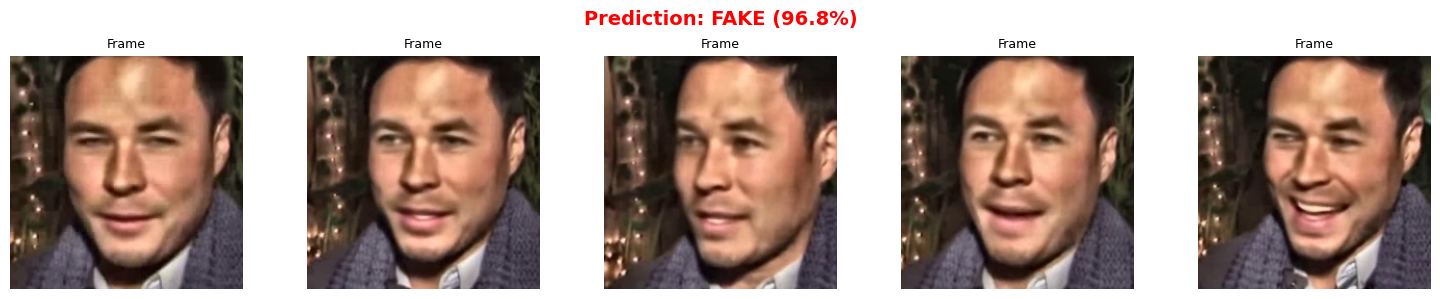

In [30]:
# ============================================================
# CELL 22 — Demo: upload & predict
# ============================================================
from google.colab import files
import matplotlib.pyplot as plt

print("Upload a video file:")
uploaded = files.upload()

for fname in uploaded:
    print(f"\nProcessing: {fname}")
    try:
        result = predict_video(fname)
    except Exception as e:
        print(f"  Error: {e}")
        continue

    tmp_dir    = "/content/_infer_tmp"
    frame_files = sorted(os.listdir(tmp_dir))[:5]
    if frame_files:
        fig, axes = plt.subplots(1, len(frame_files), figsize=(15, 3))
        if len(frame_files) == 1:
            axes = [axes]
        for ax, fn in zip(axes, frame_files):
            img = Image.open(os.path.join(tmp_dir, fn))
            ax.imshow(img); ax.axis("off")
            ax.set_title("Frame", fontsize=9)
        color = "red" if result["prediction"] == "FAKE" else "green"
        plt.suptitle(
            f"Prediction: {result['prediction']} ({result['confidence'] * 100:.1f}%)",
            fontsize=14, fontweight="bold", color=color
        )
        plt.tight_layout()
        plt.show()
